In [2]:
#Importation of libraries and dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import time

data = pd.read_csv("cicids2017_cleaned.csv");

print(data.shape)

(2520751, 61)


In [3]:
data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Attack Type
0,54865,3,2,12,6,6,6.0,0.0,0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Normal Traffic
1,55054,109,1,6,6,6,6.0,0.0,6,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Normal Traffic
2,55055,52,1,6,6,6,6.0,0.0,6,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Normal Traffic
3,46236,34,1,6,6,6,6.0,0.0,6,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Normal Traffic
4,54863,3,2,12,6,6,6.0,0.0,0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Normal Traffic


In [4]:
#1. Data Preparation 

X = data.drop('Attack Type', axis=1)
y = data['Attack Type']

# Encode the target variable 
le = LabelEncoder()
y_encoded = le.fit_transform(y)

label_mapping = dict(zip(le.transform(le.classes_), le.classes_))
print(f"Target Encoding Mapping: {label_mapping}")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

Target Encoding Mapping: {0: 'Bots', 1: 'Brute Force', 2: 'DDoS', 3: 'DoS', 4: 'Normal Traffic', 5: 'Port Scanning', 6: 'Web Attacks'}
Training shape: (1764525, 60)
Testing shape: (756226, 60)


In [5]:
#2. Defining Pipelines
pipelines = {
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', DecisionTreeClassifier(class_weight='balanced',max_depth=5, random_state=42))
    ]),
    
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(n_estimators=100, max_depth=5,class_weight='balanced', random_state=42, n_jobs=-1))
    ]),
    
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000, n_jobs=-1))
    ])
}

#3. Training and Evaluation Loop

results = {}

print("\n--- Starting Model Training & Evaluation ---\n")

for name, pipe in pipelines.items():
    print(f"Processing: {name}...")
    start_time = time.time()
    
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    
    duration = time.time() - start_time
    
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    
    # Output results
    print(f"-> {name} trained in {duration:.2f} seconds.")
    print(f"-> Accuracy: {accuracy:.4f}")
    print("-> Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    print("-" * 60)
    print("\n")


--- Starting Model Training & Evaluation ---

Processing: Decision Tree...
-> Decision Tree trained in 22.46 seconds.
-> Accuracy: 0.9145
-> Classification Report:
                precision    recall  f1-score   support

          Bots       0.04      0.99      0.08       584
   Brute Force       0.81      1.00      0.89      2745
          DDoS       0.49      1.00      0.66     38404
           DoS       0.98      0.90      0.94     58124
Normal Traffic       1.00      0.91      0.95    628518
 Port Scanning       0.94      0.93      0.93     27208
   Web Attacks       0.09      0.92      0.17       643

      accuracy                           0.91    756226
     macro avg       0.62      0.95      0.66    756226
  weighted avg       0.97      0.91      0.93    756226

------------------------------------------------------------


Processing: Random Forest...
-> Random Forest trained in 28.81 seconds.
-> Accuracy: 0.9316
-> Classification Report:
                precision    recall

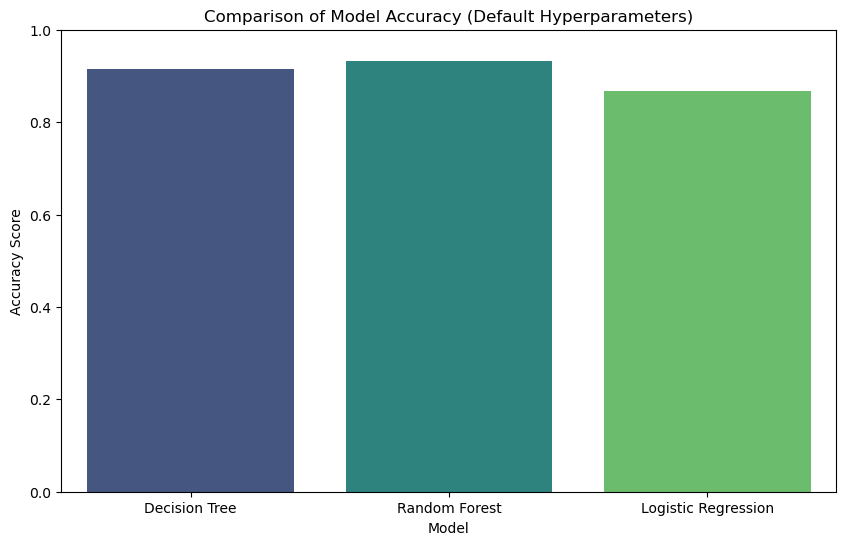

In [6]:
#4. Models Comparison Visualization

results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
plt.title('Comparison of Model Accuracy (Default Hyperparameters)')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.ylabel('Accuracy Score')
plt.show()

In [7]:
# 5: Hyperparameter optimisation with grid search
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 10, 50],
    'criterion': ['gini', 'entropy']
}

dt = DecisionTreeClassifier(random_state=42)

# Grid Search with Cross Validation
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=3,            
    n_jobs=1,       
    verbose=1,
    scoring='f1_weighted'
)


X_sample, _, y_sample, _ = train_test_split(
    X_train, y_train, 
    train_size=50000,  #Only 50k lines are kept for optimisation.
    stratify=y_train,  
    random_state=42
)
grid_search.fit(X_sample, y_sample)

best_tree = grid_search.best_estimator_
print(f"Best Tree Parameters: {grid_search.best_params_}")
print(f"Best Tree Score: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Tree Parameters: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 2}
Best Tree Score: 0.9969


In [14]:
#6: ENSEMBLE LEARNING
#Bagging Classifier
from sklearn.ensemble import BaggingClassifier, VotingClassifier
print("\n--- Step 2: Bagging Classifier ---")

bagging_model = BaggingClassifier(
    estimator=best_tree,
    n_estimators=10,
    n_jobs=-1,
    random_state=42
)

bagging_model.fit(X_train, y_train)
print("Bagging Model trained.")
print(f"Bagging Accuracy: {bagging_model.score(X_test, y_test):.4f}")
y_pred_bagging = bagging_model.predict(X_test)
print("\n--- Bagging Classifier Results ---")
print(classification_report(y_test, y_pred_bagging, target_names=le.classes_))


--- Step 2: Bagging Classifier ---
Bagging Model trained.
Bagging Accuracy: 0.9990

--- Bagging Classifier Results ---
                precision    recall  f1-score   support

          Bots       0.86      0.77      0.81       584
   Brute Force       1.00      1.00      1.00      2745
          DDoS       1.00      1.00      1.00     38404
           DoS       1.00      1.00      1.00     58124
Normal Traffic       1.00      1.00      1.00    628518
 Port Scanning       0.99      1.00      0.99     27208
   Web Attacks       0.99      0.98      0.99       643

      accuracy                           1.00    756226
     macro avg       0.98      0.96      0.97    756226
  weighted avg       1.00      1.00      1.00    756226



In [15]:
#Voting Classifier
print("\n--- Step 3: Voting Classifier ---")

lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1)

voting_clf = VotingClassifier(
    estimators=[
        ('optimized_tree', best_tree),
        ('logistic', lr_model),
    ],
    voting='soft', 
    n_jobs=-1
)

voting_clf.fit(X_train, y_train)
print("Voting Classifier trained.")

y_pred_voting = voting_clf.predict(X_test)
print("\n--- Voting Classifier Results ---")
print(classification_report(y_test, y_pred_voting, target_names=le.classes_))


--- Step 3: Voting Classifier ---
Voting Classifier trained.

--- Voting Classifier Results ---
                precision    recall  f1-score   support

          Bots       0.73      0.89      0.80       584
   Brute Force       0.99      1.00      1.00      2745
          DDoS       1.00      1.00      1.00     38404
           DoS       1.00      1.00      1.00     58124
Normal Traffic       1.00      1.00      1.00    628518
 Port Scanning       0.99      1.00      0.99     27208
   Web Attacks       0.98      0.98      0.98       643

      accuracy                           1.00    756226
     macro avg       0.96      0.98      0.97    756226
  weighted avg       1.00      1.00      1.00    756226




--- Comparaison des Performances ---
Baseline DT -> Accuracy: 0.9145, F1-Score: 0.9336
Optimized DT -> Accuracy: 0.9969, F1-Score: 0.9969
Bagging DT -> Accuracy: 0.9990, F1-Score: 0.9990
Voting (DT+LR) -> Accuracy: 0.9988, F1-Score: 0.9988


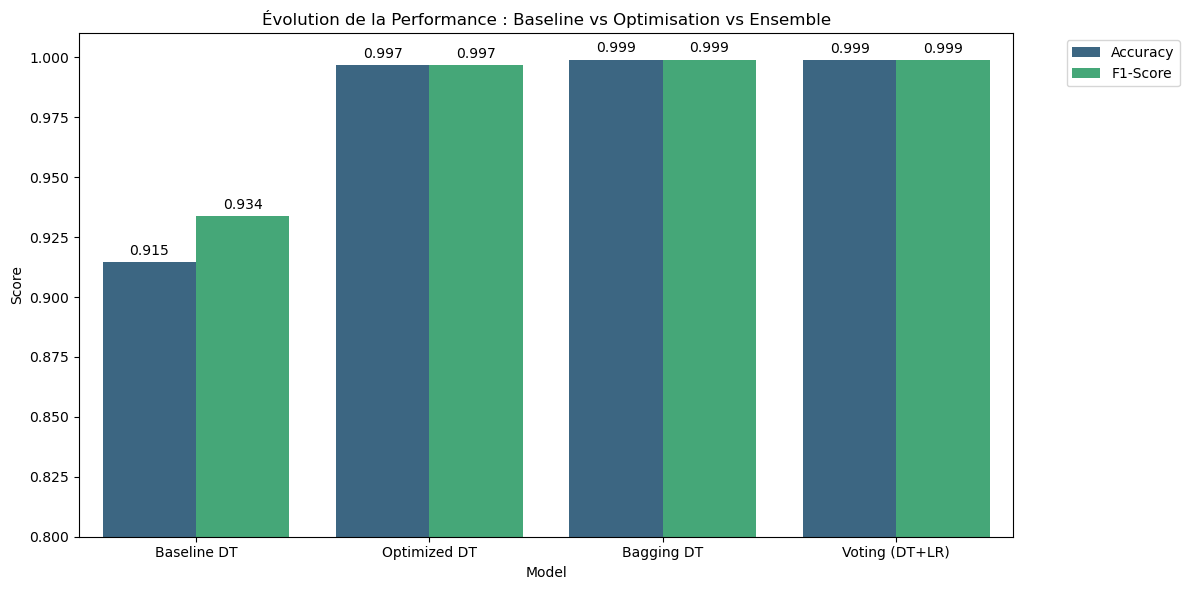


 Best Model : Bagging DT

--- Classification Report (Bagging DT) ---
                precision    recall  f1-score   support

          Bots       0.86      0.77      0.81       584
   Brute Force       1.00      1.00      1.00      2745
          DDoS       1.00      1.00      1.00     38404
           DoS       1.00      1.00      1.00     58124
Normal Traffic       1.00      1.00      1.00    628518
 Port Scanning       0.99      1.00      0.99     27208
   Web Attacks       0.99      0.98      0.99       643

      accuracy                           1.00    756226
     macro avg       0.98      0.96      0.97    756226
  weighted avg       1.00      1.00      1.00    756226

[[   449      0      0      0    135      0      0]
 [     0   2741      0      0      4      0      0]
 [     0      0  38393      0     11      0      0]
 [     0      0      0  58096     24      4      0]
 [    72      2      5    103 628041    292      3]
 [     0      0      0      9     53  27144      2]

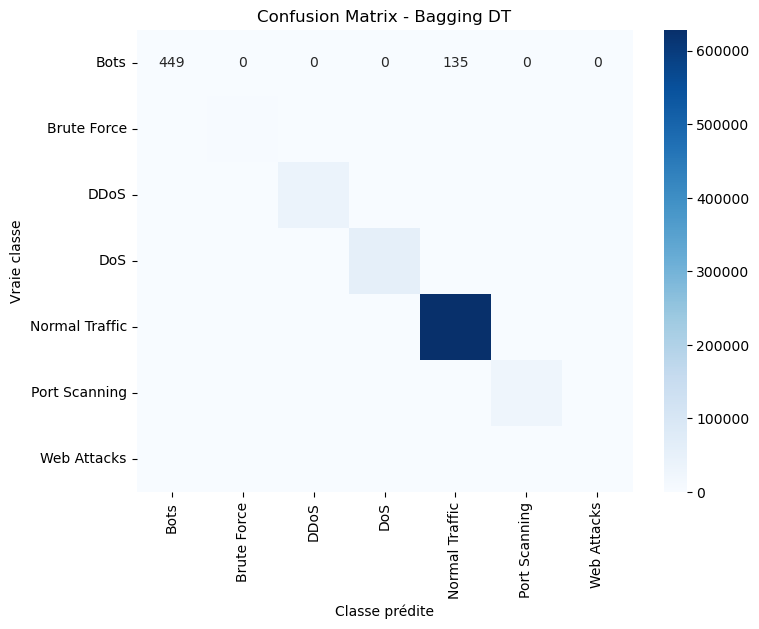

In [16]:
#7 Final comparative evalutation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

baseline_model = pipelines['Decision Tree']

models = {
    "Baseline DT": baseline_model,      
    "Optimized DT": best_tree,            
    "Bagging DT": bagging_model,         
    "Voting (DT+LR)": voting_clf         
}

results = []

print("\n--- Comparaison des Performances ---")

for name, model in models.items():
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append({'Model': name, 'Accuracy': acc, 'F1-Score': f1})
    print(f"{name} -> Accuracy: {acc:.4f}, F1-Score: {f1:.4f}")

results_df = pd.DataFrame(results)

#VISUALISATION 

plt.figure(figsize=(12, 6))
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

ax = sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric", palette="viridis")


for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)

plt.title("Évolution de la Performance : Baseline vs Optimisation vs Ensemble")
plt.ylim(0.80, 1.01) 
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Analysis of the best model 

best_model_name = results_df.loc[results_df['F1-Score'].idxmax()]['Model']
print(f"\n Best Model : {best_model_name}")

best_model_instance = models[best_model_name]
y_pred_best = best_model_instance.predict(X_test)

print(f"\n--- Classification Report ({best_model_name}) ---")

print(classification_report(y_test, y_pred_best, target_names=le.classes_))

# Confusion matrix 
cm = confusion_matrix(y_test, y_pred_best)
print(cm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')
plt.show()

In [17]:
#8 Overfitting & Underfitting Analysis 

print("\n--- Overfitting/Underfitting Analysis ---\n")

for name, pipe in models.items():
    
    train_score = pipe.score(X_train, y_train)
    
    test_score = pipe.score(X_test, y_test)
    
    print(f"Model: {name}")
    print(f"  Training Accuracy: {train_score:.4f}")
    print(f"  Testing Accuracy:  {test_score:.4f}")
    
    gap = train_score - test_score
    if gap > 0.05: # 
        print("  -> STATUS: OVERFITTING DETECTED (Gap > 5%)")
    elif train_score < 0.70: 
        print("  -> STATUS: UNDERFITTING DETECTED (Low Training Score)")
    else:
        print("  -> STATUS: GOOD BALANCE")
    print("-" * 40)


--- Overfitting/Underfitting Analysis ---

Model: Baseline DT
  Training Accuracy: 0.9141
  Testing Accuracy:  0.9145
  -> STATUS: GOOD BALANCE
----------------------------------------
Model: Optimized DT
  Training Accuracy: 0.9971
  Testing Accuracy:  0.9969
  -> STATUS: GOOD BALANCE
----------------------------------------
Model: Bagging DT
  Training Accuracy: 0.9995
  Testing Accuracy:  0.9990
  -> STATUS: GOOD BALANCE
----------------------------------------
Model: Voting (DT+LR)
  Training Accuracy: 0.9993
  Testing Accuracy:  0.9988
  -> STATUS: GOOD BALANCE
----------------------------------------
